In [2]:
# 步骤1：环境准备
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macos
# plt.rcParams['font.sans-serif'] = ['SimHei']  # windows
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 步骤2：参数设置
symbol = 'AAPL'        # 股票代码
period = '1y'          # 时间周期
ma1_period = 10         # MA周期
ma2_period = 20         # MA周期

In [4]:
# 步骤3：获取股票数据
ticker = yf.Ticker(symbol)
df = ticker.history(period=period)
print(f"✅ 数据获取完成，共 {len(df)} 个交易日")

✅ 数据获取完成，共 251 个交易日


In [9]:
# [100,50,20,100] => 当日的涨跌情况（收盘价相对于昨天是涨还是跌？）=>[+,-,+,-]=> *Volume=>*.cumsum
# help(df.diff)
np.sign?

Call signature:  np.sign(*args, **kwargs)
Type:            ufunc
String form:     <ufunc 'sign'>
File:            /Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/numpy/__init__.py
Docstring:      
sign(x, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature, extobj])

Returns an element-wise indication of the sign of a number.

The `sign` function returns ``-1 if x < 0, 0 if x==0, 1 if x > 0``.  nan
is returned for nan inputs.

For complex inputs, the `sign` function returns
``sign(x.real) + 0j if x.real != 0 else sign(x.imag) + 0j``.

complex(nan, 0) is returned for complex nan inputs.

Parameters
----------
x : array_like
    Input values.
out : ndarray, None, or tuple of ndarray and None, optional
    A location into which the result is stored. If provided, it must have
    a shape that the inputs broadcast to. If not provided or None,
    a freshly-allocated array is returned. A tuple (possible only as a
    ke

In [13]:
# 步骤4：计算 OBV => 当日涨则累加Volume，跌则累减Volume [+100,-50,....]
df['OBV'] = np.sign(df['Close'].diff()) * df['Volume']
df['OBV'] = df['OBV'].fillna(0).cumsum()
df['OBV_MA'] = df['OBV'].rolling(ma1_period).mean()

df[['OBV','OBV_MA']]

,OBV,OBV_MA
Date,,
2024-10-08 00:00:00-04:00,0.0,NaN
2024-10-09 00:00:00-04:00,33591100.0,NaN
2024-10-10 00:00:00-04:00,5407600.0,NaN
2024-10-11 00:00:00-04:00,-26351600.0,NaN
2024-10-14 00:00:00-04:00,13530500.0,NaN
...,...,...
2025-10-02 00:00:00-04:00,859305000.0,794802030.0
2025-10-03 00:00:00-04:00,908460600.0,809816090.0
2025-10-06 00:00:00-04:00,863796500.0,809812000.0


In [14]:
# 步骤5：计算 Volume_MA
df['Volume_MA1'] = df['Volume'].rolling(ma1_period).mean()
df['Volume_MA2'] = df['Volume'].rolling(ma2_period).mean()

df[['Volume','Volume_MA1','Volume_MA2']]

,Volume,Volume_MA1,Volume_MA2
Date,,,
2024-10-08 00:00:00-04:00,31855700,NaN,NaN
2024-10-09 00:00:00-04:00,33591100,NaN,NaN
2024-10-10 00:00:00-04:00,28183500,NaN,NaN
2024-10-11 00:00:00-04:00,31759200,NaN,NaN
2024-10-14 00:00:00-04:00,39882100,NaN,NaN
...,...,...,...
2025-10-02 00:00:00-04:00,42630200,64229210.0,59941385.00
2025-10-03 00:00:00-04:00,49155600,52770640.0,59655645.00
2025-10-06 00:00:00-04:00,44664100,46685310.0,59438875.00


In [15]:
# 步骤6：统计趋势
print("📊 OBV 历史统计")
print("=" * 50)
obv_change = df['OBV'].diff().dropna()
obv_up_days = (obv_change > 0).sum()
obv_down_days = (obv_change < 0).sum()

print(f"上涨天数：{obv_up_days}")
print(f"下跌天数：{obv_down_days}")
print(f"上升比例：{obv_up_days / len(obv_change) * 100:.2f}%")
print(f"最近OBV变化：{obv_change.iloc[-1]:.2f}")

print("\n📊 Volume 历史统计")
print("=" * 50)
volume_mean = df['Volume'].mean()
volume_std = df['Volume'].std()
volume_latest = df['Volume'].iloc[-1]
volume_ratio = volume_latest / volume_mean

print(f"成交量均值：{volume_mean:.0f}")
print(f"成交量标准差：{volume_std:.0f}")
print(f"当前成交量：{volume_latest:.0f}")
print(f"量能倍数：{volume_ratio:.2f}倍")

📊 OBV 历史统计
上涨天数：134
下跌天数：115
上升比例：53.60%
最近OBV变化：17326545.00

📊 Volume 历史统计
成交量均值：53674859
成交量标准差：23403092
当前成交量：17326545
量能倍数：0.32倍


In [16]:
# 步骤7：当前趋势判断
if df['OBV'].iloc[-1] > df['OBV_MA'].iloc[-1]:
    trend = "资金流入（OBV位于均线上方）"
elif df['OBV'].iloc[-1] < df['OBV_MA'].iloc[-1]:
    trend = "资金流出（OBV位于均线下方）"
else:
    trend = "资金流向平稳"

print("\n📈 当前趋势判断")
print("=" * 50)
print(f"当前资金趋势：{trend}")

# Volume趋势判断
print(f"\n📊 成交量趋势判断")
print("=" * 50)
if volume_ratio > 1.5:
    volume_signal = "放量突破"
elif volume_ratio > 1.2:
    volume_signal = "温和放量"
elif volume_ratio < 0.7:
    volume_signal = "缩量整理"
else:
    volume_signal = "量能正常"

print(f"成交量信号：{volume_signal}")

# 综合判断
if trend == "资金流入（OBV位于均线上方）" and volume_ratio > 1.2:
    print("\n🎯 综合信号：强势上涨")
elif trend == "资金流出（OBV位于均线下方）" and volume_ratio > 1.2:
    print("\n🎯 综合信号：放量下跌")
elif trend == "资金流入（OBV位于均线上方）" and volume_ratio < 0.7:
    print("\n🎯 综合信号：缩量上涨（谨慎）")
else:
    print("\n🎯 综合信号：观望等待")


📈 当前趋势判断
当前资金趋势：资金流入（OBV位于均线上方）

📊 成交量趋势判断
成交量信号：缩量整理

🎯 综合信号：缩量上涨（谨慎）


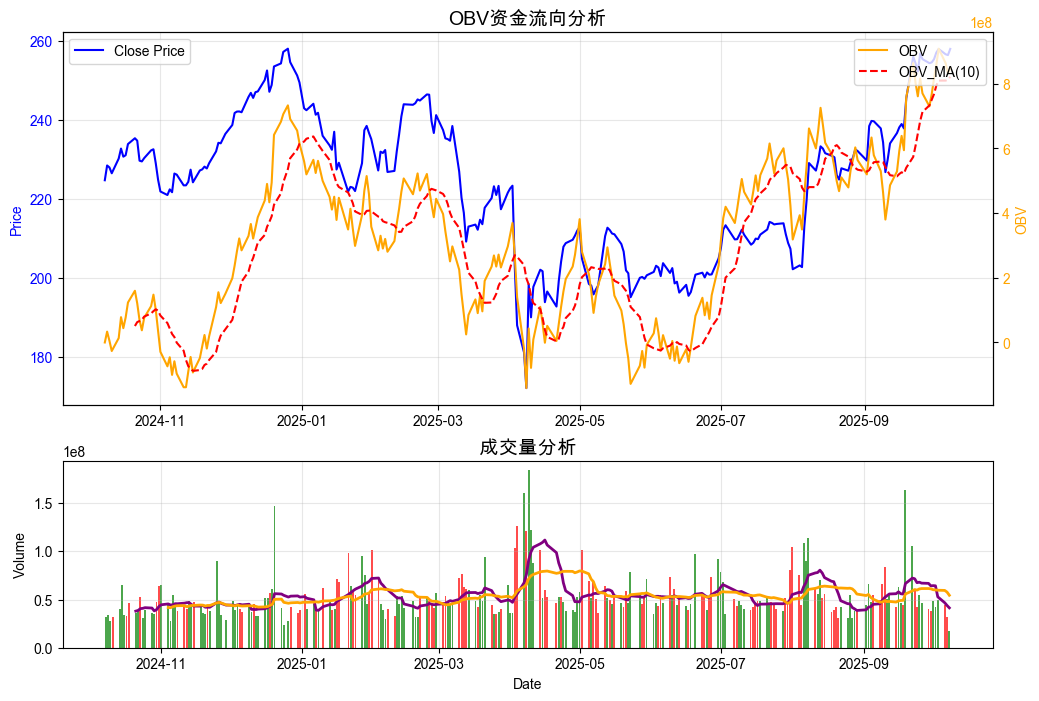

In [17]:
# 步骤8：可视化
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[2, 1])

# 上图：价格和OBV分析
ax1.plot(df['Close'], color='blue', label='Close Price', linewidth=1.5)
ax1.set_ylabel('Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax1_obv = ax1.twinx()
ax1_obv.plot(df['OBV'], color='orange', label='OBV', linewidth=1.5)
ax1_obv.plot(df['OBV_MA'], color='red', linestyle='--', label='OBV_MA(10)')
ax1_obv.set_ylabel('OBV', color='orange')
ax1_obv.tick_params(axis='y', labelcolor='orange')

ax1.set_title("OBV资金流向分析", fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1_obv.legend(loc='upper right')
ax1.grid(alpha=0.3)

# 下图：成交量分析
ax2.bar(df.index, df['Volume'], color=['red' if close < open else 'green' 
                                       for close, open in zip(df['Close'], df['Open'])], 
        alpha=0.7, width=0.8)
ax2.set_ylabel('Volume', color='black')
ax2.set_xlabel('Date')
ax2.set_title("成交量分析", fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)

# 添加成交量移动平均线
ax2.plot(df.index, df['Volume_MA1'], color='purple', linewidth=2, label='Volume_MA1')
ax2.plot(df.index, df['Volume_MA2'], color='orange', linewidth=2, label='Volume_MA2')